# Federated Training Process
Federated learning is a distributed machine learning approach where multiple clients train models locally on their private data without sharing raw data. Instead of centralizing data, each client trains on their local dataset and sends only model weight updates to a central server. The server aggregates these updates using the Federated Averaging (FedAvg) algorithm to create an improved global model, which is then sent back to clients for the next round. This process repeats for several rounds, enabling collaborative learning while preserving data privacy and security.

**Requirements**:
 Python==3.10. It does not work in latest version of python as its seems to problem of the `ray`

#### Load imports

In [1]:
import logging
from logging import INFO, ERROR
from collections import OrderedDict
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

from flwr.common.logger import console_handler, log
from flwr.common import Metrics, NDArrays, Scalar
from flwr.client import Client, ClientApp, NumPyClient
from flwr.common import ndarrays_to_parameters, Context
from flwr.server import ServerApp, ServerConfig
from flwr.server import ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
class InfoFilter(logging.Filter):
    def filter(self, record):
        return record.levelno == INFO

console_handler.setLevel(INFO)
console_handler.addFilter(InfoFilter())

# To filter logging coming from the Simulation Engine
# so it's more readable in notebooks
backend_setup = {"init_args": {"logging_level": ERROR, "log_to_driver": False}}


### Data Filtering Utilities

Helper functions to filter the MNIST dataset by digit classes:
- `include_digits`: Returns a subset containing only specified digits
- `exclude_digits`: Returns a subset excluding specified digits

These functions enable creating non-IID (non-independent and identically distributed)
data partitions across clients, which is a key characteristic of federated learning scenarios.

In [3]:
def include_digits(dataset, included_digits):
    including_indices = [
        idx for idx in range(len(dataset)) if dataset[idx][1] in included_digits
    ]
    return torch.utils.data.Subset(dataset, including_indices)


def exclude_digits(dataset, excluded_digits):
    including_indices = [
        idx for idx in range(len(dataset)) if dataset[idx][1] not in excluded_digits
    ]
    return torch.utils.data.Subset(dataset, including_indices)


### Training Dataset Setup

Create non-IID training data partitions for 3 clients:
1. Load the full MNIST training dataset and split it into 3 equal parts
2. Each client receives data with specific digits excluded:
   - **Client 1**: Excludes digits [1, 3, 7] - trains on [0, 2, 4, 5, 6, 8, 9]
   - **Client 2**: Excludes digits [2, 5, 8] - trains on [0, 1, 3, 4, 6, 7, 9]
   - **Client 3**: Excludes digits [4, 6, 9] - trains on [0, 1, 2, 3, 5, 7, 8]

This simulates a realistic federated learning scenario where each client
has access to only a subset of the complete data distribution.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.MNIST(
    "./MNIST_data/", download=True, train=True, transform=transform
)

total_length = len(trainset)
split_size = total_length // 3
torch.manual_seed(42)
part1, part2, part3 = random_split(trainset, [split_size] * 3)

part1 = exclude_digits(part1, excluded_digits=[1, 3, 7])
part2 = exclude_digits(part2, excluded_digits=[2, 5, 8])
part3 = exclude_digits(part3, excluded_digits=[4, 6, 9])

train_sets = [part1, part2, part3]

#### Set up the MNIST testing datasets.

In [5]:
testset = datasets.MNIST(
    "./MNIST_data/", download=True, train=False, transform=transform
)
print("Number of examples in `testset`:", len(testset))

testset_137 = include_digits(testset, [1, 3, 7])
testset_258 = include_digits(testset, [2, 5, 8])
testset_469 = include_digits(testset, [4, 6, 9])

Number of examples in `testset`: 10000


#### Define training and testing in the pipeline

In [6]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = self.relu(x)
        x = self.out(x)
        return x

### Model Training Function

Train the neural network on a client's local dataset:
- **Batch Size**: 64 samples per batch
- **Epochs**: 10 complete passes through the training data
- **Optimizer**: SGD with learning rate 0.01 and momentum 0.9
- **Loss Function**: Cross-Entropy Loss for multi-class classification

This function is called locally on each client during the federated training process.

In [7]:
def train_model(model, train_set):
    batch_size = 64
    num_epochs = 10

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

### Weight Management Functions

Functions for serializing and deserializing model weights:
- `set_weights`: Load parameters from a numpy array into the model
- `get_weights`: Extract model parameters as numpy arrays

These functions enable the Flower framework to exchange model weights
between clients and the central server without sharing raw data.

In [8]:
# Sets the parameters of the model
def set_weights(net, parameters):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict(
        {k: torch.tensor(v) for k, v in params_dict}
    )
    net.load_state_dict(state_dict, strict=True)

# Retrieves the parameters from the model
def get_weights(net):
    ndarrays = [
        val.cpu().numpy() for _, val in net.state_dict().items()
    ]
    return ndarrays

### Flower Client Implementation

Define the `FlowerClient` class that wraps the local training and evaluation logic:
- `fit`: Receives global model weights, trains locally, returns updated weights
- `evaluate`: Receives global model weights, evaluates on local test data, returns metrics

Each client in the federated learning system is an instance of this class.

In [9]:
class FlowerClient(NumPyClient):
    def __init__(self, net, trainset, testset):
        self.net = net
        self.trainset = trainset
        self.testset = testset

    # Train the model
    def fit(self, parameters, config):
        set_weights(self.net, parameters)
        train_model(self.net, self.trainset)
        return get_weights(self.net), len(self.trainset), {}

    # Test the model
    def evaluate(self, parameters: NDArrays, config: Dict[str, Scalar]):
        set_weights(self.net, parameters)
        loss, accuracy = evaluate_model(self.net, self.testset)
        return loss, len(self.testset), {"accuracy": accuracy}

### Client Factory Function

`client_fn` is a factory function that Flower calls to create client instances:
- Creates a fresh model for each client
- Assigns the appropriate data partition based on the client's node ID
- Returns a `FlowerClient` wrapped as a Flower `Client`

This function enables Flower to manage multiple clients in the simulation.

In [10]:
# Client function
def client_fn(context: Context) -> Client:
    net = SimpleModel()
    partition_id = int(context.node_config["partition-id"])
    client_train = train_sets[int(partition_id)]
    client_test = testset
    return FlowerClient(net, client_train, client_test).to_client()

### Create an instance of the ClientApp.

In [11]:
client = ClientApp(client_fn)

### Model Evaluation Function

Evaluate the model on a test dataset:
- Computes average loss and accuracy over the entire test set
- Uses the same batch size (64) and loss function as training
- Runs in evaluation mode (`model.eval()`) with no gradient computation

Returns the average loss and accuracy for monitoring training progress.

In [12]:
def evaluate_model(model, test_set):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    test_loader = DataLoader(test_set, batch_size=64, shuffle=False)
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss = criterion(outputs, labels)
            total_loss += loss.item()

    accuracy = correct / total
    average_loss = total_loss / len(test_loader)
    # print(f"Test Accuracy: {accuracy:.4f}, Average Loss: {average_loss:.4f}")
    return average_loss, accuracy


In [13]:
def compute_confusion_matrix(model, testset):
    model.eval()
    # Initialize lists to store true labels and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over the test set to get predictions
    for image, label in testset:
        # Forward pass through the model to get predictions
        output = model(image.unsqueeze(0))  # Add batch dimension
        _, predicted = torch.max(output, 1)

        # Append true and predicted labels to lists
        true_labels.append(label)
        predicted_labels.append(predicted.item())

    # Convert lists to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    return cm


def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", linewidths=0.5)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

### Global Evaluation Callback

The `evaluate` function is called by the server after each federated round:
- Loads the global model parameters
- Evaluates on the full test set and each digit subset ([1,3,7], [2,5,8], [4,6,9])
- Logs accuracy metrics for monitoring federated learning progress
- After round 3, computes and plots the confusion matrix for the final model

This function runs on the server side to track global model performance.

In [14]:
def evaluate(server_round, parameters, config):
    net = SimpleModel()
    set_weights(net, parameters)

    _, accuracy = evaluate_model(net, testset)
    _, accuracy137 = evaluate_model(net, testset_137)
    _, accuracy258 = evaluate_model(net, testset_258)
    _, accuracy469 = evaluate_model(net, testset_469)

    log(INFO, "test accuracy on all digits: %.4f", accuracy)
    log(INFO, "test accuracy on [1,3,7]: %.4f", accuracy137)
    log(INFO, "test accuracy on [2,5,8]: %.4f", accuracy258)
    log(INFO, "test accuracy on [4,6,9]: %.4f", accuracy469)

    if server_round == 3:
        cm = compute_confusion_matrix(net, testset)
        plot_confusion_matrix(cm, "Final Global Model")

### Federated Strategy: FedAvg

Configure the Federated Averaging (FedAvg) strategy:
- `fraction_fit=1.0`: All clients participate in each training round
- `fraction_evaluate=0.0`: Skip client-side evaluation (use server-side eval instead)
- `initial_parameters`: Start with random weights from an untrained model
- `evaluate_fn`: Use the custom evaluate function for server-side evaluation
- `num_rounds=3`: Run 3 federated training rounds

FedAvg aggregates client model updates by computing the weighted average
of model parameters based on the number of training samples per client.

In [15]:
net = SimpleModel()
params = ndarrays_to_parameters(get_weights(net))

def server_fn(context: Context):
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=0.0,
        initial_parameters=params,
        evaluate_fn=evaluate,
    )
    config=ServerConfig(num_rounds=3)
    return ServerAppComponents(
        strategy=strategy,
        config=config,
    )

### ServerApp Instantiation

Create the `ServerApp` instance that bundles the server configuration.
The server orchestrates the federated learning process by:
- Sampling clients for each round
- Collecting model updates from clients
- Aggregating updates using the FedAvg strategy
- Running the evaluation callback after each round

In [16]:
server = ServerApp(server_fn=server_fn)

### Run Federated Learning Simulation

Start the federated learning simulation using Flower's simulation engine:
- `server_app`: The server application that orchestrates training
- `client_app`: The client application that handles local training
- `num_supernodes=3`: Simulate 3 clients (matching our 3 data partitions)
- `backend_config`: Ray backend configuration with filtered logging

The simulation runs 3 rounds of federated training where:
1. Server sends global model to all clients
2. Each client trains locally on their data partition
3. Clients send updated weights back to server
4. Server aggregates weights using FedAvg
5. Server evaluates the global model on test data

INFO :      Starting Flower ServerApp, config: num_rounds=3, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      test accuracy on all digits: 0.1267
INFO :      test accuracy on [1,3,7]: 0.2275
INFO :      test accuracy on [2,5,8]: 0.1201
INFO :      test accuracy on [4,6,9]: 0.0380
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
/home/sanjeev/Templates/old-projects/Machine-learning-Project/.venv/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
INFO :      aggregate_fit: received

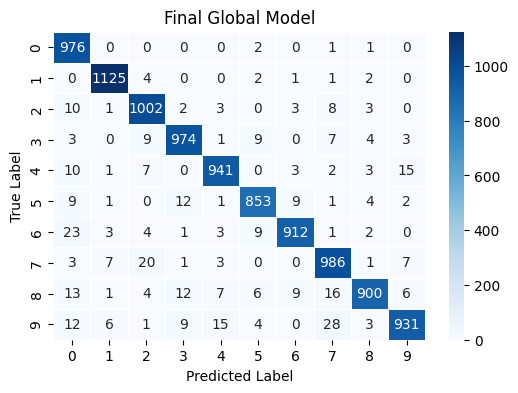

INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 66.90s
INFO :      


In [17]:
# Initiate the simulation passing the server and client apps
# Specify the number of super nodes that will be selected on every round
run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=3,
    backend_config=backend_setup,
)